# Predictivo - Mental Health 2026

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Librerias para exportar
import pandas as pd #manipular conjuntos de datos (dataframe)
import numpy as np # operaciones matricas
import matplotlib.pyplot as plt # gráficas

In [4]:
# Cargar la base de datos
df = pd.read_csv("mental_health_final_project_2026.csv")

In [5]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2301 entries, 0 to 2300
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   tipo_caso              2301 non-null   object
 1   sexo                   2301 non-null   object
 2   edad_paciente          2301 non-null   int64 
 3   reg_seg_social         2301 non-null   object
 4   estado_civil           2301 non-null   int64 
 5   escolaridad            2301 non-null   int64 
 6   conflict_pareja_ex     2301 non-null   int64 
 7   enf_cron_dol_disc      2301 non-null   int64 
 8   probl_econ             2301 non-null   int64 
 9   muerte_fam             2301 non-null   int64 
 10  probl_educ             2301 non-null   int64 
 11  probl_jurid            2301 non-null   int64 
 12  suic_fam_amig          2301 non-null   int64 
 13  maltrato_fis_psic_sex  2301 non-null   int64 
 14  probl_lab              2301 non-null   int64 
 15  probl_fam            

In [6]:
#correción de tipo de datos
df["tipo_caso"]=df["tipo_caso"].astype("category")
df["sexo"]=df["sexo"].astype("category")
df["reg_seg_social"]=df["reg_seg_social"].astype("category")
df["estado_civil"]=df["estado_civil"].astype("category")
df["escolaridad"]=df["escolaridad"].astype("category")
df["tipo_sust"]=df["tipo_sust"].astype("category")
print(df)
df.info()

     tipo_caso sexo  edad_paciente reg_seg_social estado_civil escolaridad  \
0      Intento    M             31              C            1           1   
1      Intento    M             31              C            1          13   
2      Intento    M             31              C            1          14   
3      Intento    M             31              E            1           1   
4      Intento    M             31              C            1          14   
...        ...  ...            ...            ...          ...         ...   
2296   Intento    H             89              C            3          14   
2297   Intento    H             90              C            4          13   
2298   Intento    H             91              S            2           1   
2299   Intento    H             92              C            2          14   
2300   Intento    M             96              C            4           2   

      conflict_pareja_ex  enf_cron_dol_disc  probl_econ  muerte

In [7]:
#Creamos variables dummy para convertir  las categorías a números
df = pd.get_dummies(df, columns=['reg_seg_social', 'estado_civil', 'escolaridad', 'tipo_sust'], drop_first=False, dtype=int)
df = pd.get_dummies(df, columns=['sexo', 'tipo_caso'], drop_first=True, dtype=int)
df.head()

,edad_paciente,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,probl_educ,probl_jurid,suic_fam_amig,maltrato_fis_psic_sex,probl_lab,...,escolaridad_14,tipo_sust_1,tipo_sust_2,tipo_sust_3,tipo_sust_5,tipo_sust_6,tipo_sust_7,tipo_sust_8,sexo_M,tipo_caso_Suicidio
0,31,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,31,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,31,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0
3,31,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4,31,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0


In [8]:
print(df.columns)

Index(['edad_paciente', 'conflict_pareja_ex', 'enf_cron_dol_disc',
       'probl_econ', 'muerte_fam', 'probl_educ', 'probl_jurid',
       'suic_fam_amig', 'maltrato_fis_psic_sex', 'probl_lab', 'probl_fam',
       'fact_des_no_ident', 'consum_spa', 'ant_fam_cond_suic',
       'ideac_suic_persist', 'plan_org_suic', 'ant_trast_psiq', 'trast_depr',
       'trast_person', 'trast_bip', 'esquizof', 'ant_viol_abus', 'abuso_alcoh',
       'fact_riesg_no_ident', 'ahorc_asfx', 'elemt_cortop', 'arm_fuego',
       'inmolac', 'lanz_vacio', 'intoxicacion', 'lanz_vehic',
       'lanz_cuerp_agua', 'mec_no_ident', 'num_intentos', 'reg_seg_social_C',
       'reg_seg_social_E', 'reg_seg_social_I', 'reg_seg_social_N',
       'reg_seg_social_P', 'reg_seg_social_S', 'estado_civil_1',
       'estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'estado_civil_5',
       'escolaridad_1', 'escolaridad_2', 'escolaridad_3', 'escolaridad_4',
       'escolaridad_5', 'escolaridad_6', 'escolaridad_7', 'escolaridad_8',

In [9]:
df.describe()

,edad_paciente,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,probl_educ,probl_jurid,suic_fam_amig,maltrato_fis_psic_sex,probl_lab,...,escolaridad_14,tipo_sust_1,tipo_sust_2,tipo_sust_3,tipo_sust_5,tipo_sust_6,tipo_sust_7,tipo_sust_8,sexo_M,tipo_caso_Suicidio
count,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,...,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000,2301.000000
mean,31.279444,0.158627,0.033029,0.063451,0.020860,0.036506,0.010865,0.003477,0.020426,0.034333,...,0.183833,0.632334,0.036940,0.000435,0.006953,0.085615,0.024772,0.212951,0.537592,0.036940
std,16.045741,0.365407,0.178751,0.243825,0.142948,0.187586,0.103689,0.058874,0.141483,0.182122,...,0.387432,0.482275,0.188657,0.020847,0.083115,0.279855,0.155463,0.409482,0.498693,0.188657
min,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,96.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

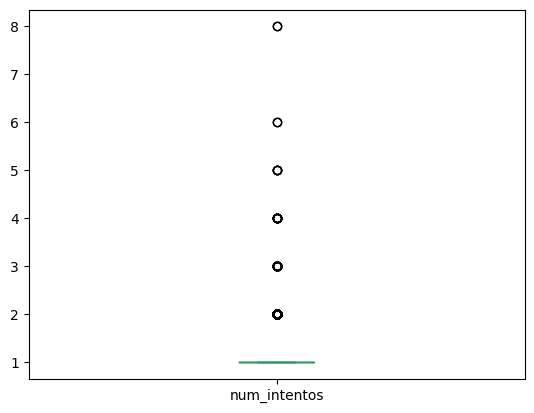

In [10]:
#División 70-30
from sklearn.model_selection import train_test_split
X = df.drop("num_intentos", axis = 1) # Variables predictoras
Y = df['num_intentos'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None)
Y_train.plot(kind='box')

In [11]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

Arbol de Regresión

In [12]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeRegressor
model_Tree = DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=10, max_depth=5)
model_Tree.fit(X_train, Y_train)#70% entrenamiento

DecisionTreeRegressor(max_depth=5, min_samples_leaf=10)

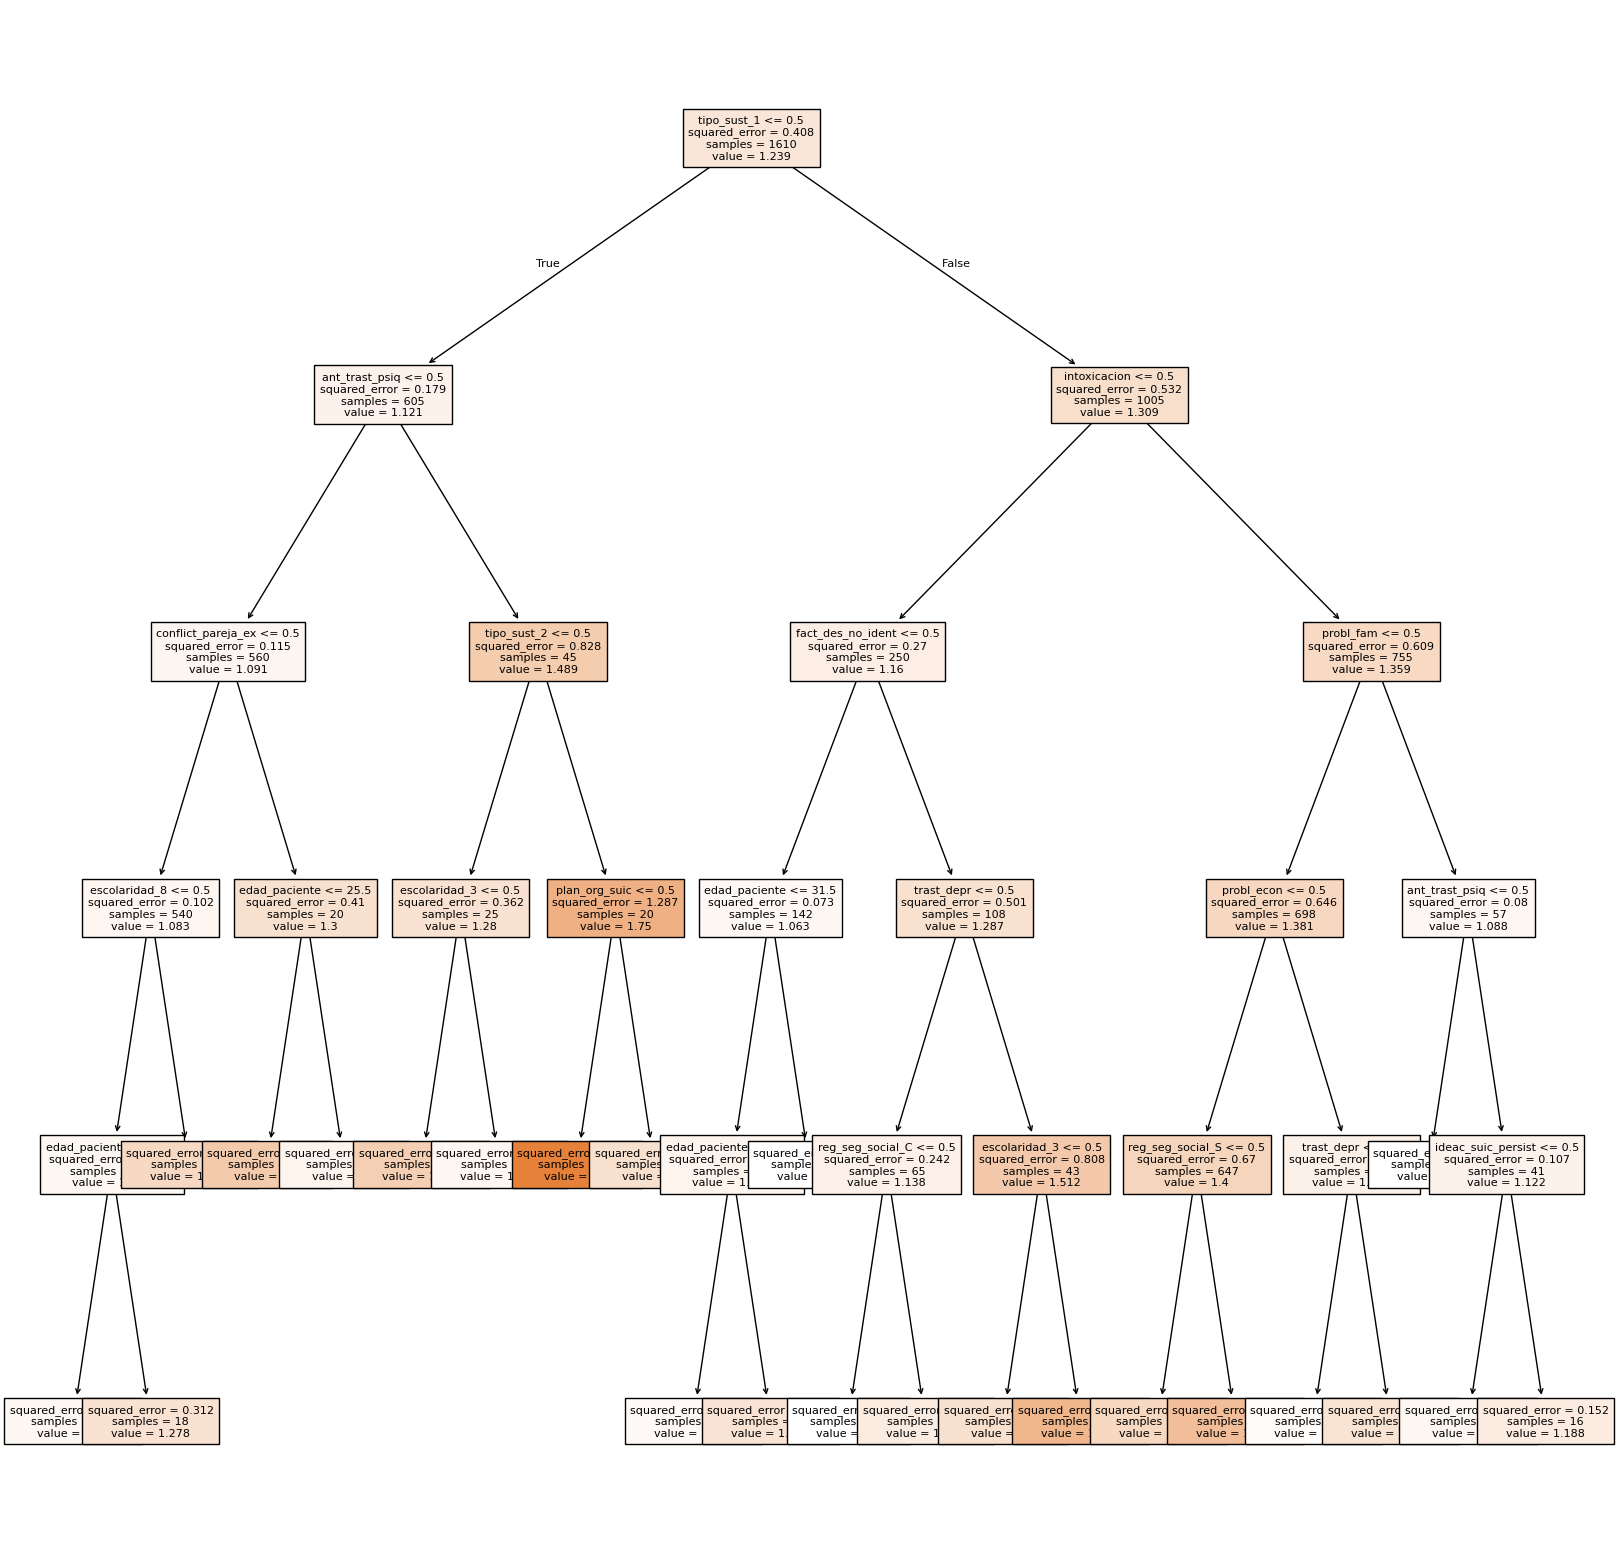

In [13]:
#Graficar el árbol
from sklearn.tree import plot_tree
nombres_variables=X_train.columns.values
plt.figure(figsize=(20,20))
plot_tree(model_Tree, feature_names=nombres_variables, filled=True,fontsize=8)
plt.show()

In [14]:
#Evaluación del árbol 30%
from sklearn import metrics
Y_pred = model_Tree.predict(X_test) #30%

#Medidas de evaluación en regresión
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Arbol']=[mse, rmse, mae, mape,max]
medidas

,Arbol
mse,0.484118
rmse,0.695786
mae,0.367701
mape,0.244437
max,6.304348


/tmp/ipykernel_3955/2783684465.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


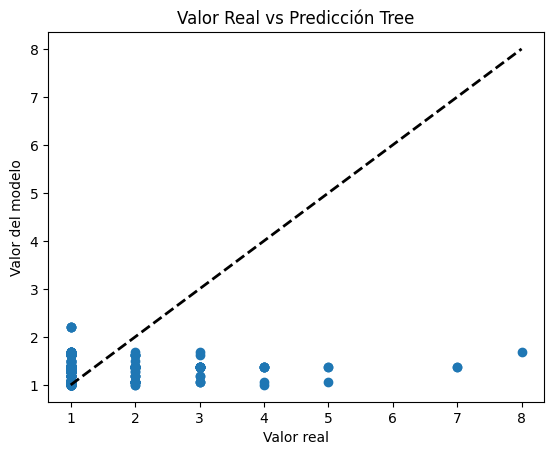

In [15]:
#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Tree')
plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos

KNN para Regresión

In [16]:
#Normalizacion de las variables numéricas
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

variables_numericas=['edad_paciente']

#Ajuste de los parametros sobre 100% de los datos (data): max - min
min_max_scaler.fit(df[variables_numericas])

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()

,edad_paciente,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,probl_educ,probl_jurid,suic_fam_amig,maltrato_fis_psic_sex,probl_lab,...,escolaridad_14,tipo_sust_1,tipo_sust_2,tipo_sust_3,tipo_sust_5,tipo_sust_6,tipo_sust_7,tipo_sust_8,sexo_M,tipo_caso_Suicidio
744,0.136364,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
61,0.261364,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1137,0.193182,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
794,0.136364,0,1,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0
2161,0.613636,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [17]:
from sklearn.neighbors import  KNeighborsRegressor
model_Knn = KNeighborsRegressor(n_neighbors=1, metric='euclidean') #minkowski
model_Knn.fit(X_train, Y_train) #70%

KNeighborsRegressor(metric='euclidean', n_neighbors=1)

         Arbol       Knn
mse   0.484118  1.092619
rmse  0.695786  1.045284
mae   0.367701  0.464544
mape  0.244437  0.333447
max   6.304348  7.000000


/tmp/ipykernel_3955/27550333.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


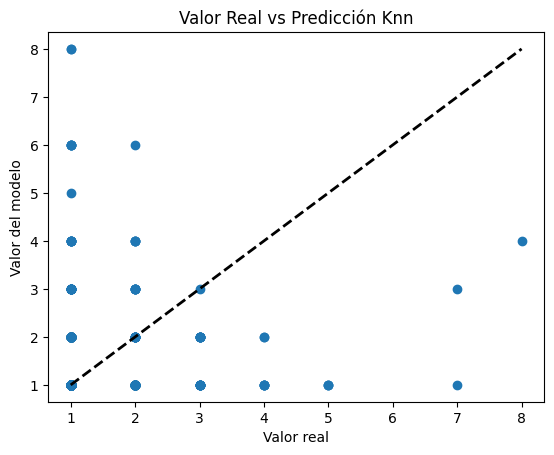

In [18]:
#Evaluación de KNN
from sklearn import metrics

Y_pred = model_Knn.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Knn']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Knn')
plt.show()

Red Neuronal para Regresión

In [19]:
from sklearn.neural_network import MLPRegressor

model_NN = MLPRegressor(activation="relu",hidden_layer_sizes=(16), learning_rate='constant',
                     learning_rate_init=0.3, momentum= 0.2, max_iter=500,  random_state=3)
model_NN.fit(X_train, Y_train)#70%

MLPRegressor(hidden_layer_sizes=16, learning_rate_init=0.3, max_iter=500,
             momentum=0.2, random_state=3)

         Arbol       Knn                  NN
mse   0.484118  1.092619  0.4980173225037954
rmse  0.695786  1.045284            0.705703
mae   0.367701  0.464544            0.402971
mape  0.244437  0.333447            0.271749
max   6.304348  7.000000            6.763256


/tmp/ipykernel_3955/3516498092.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


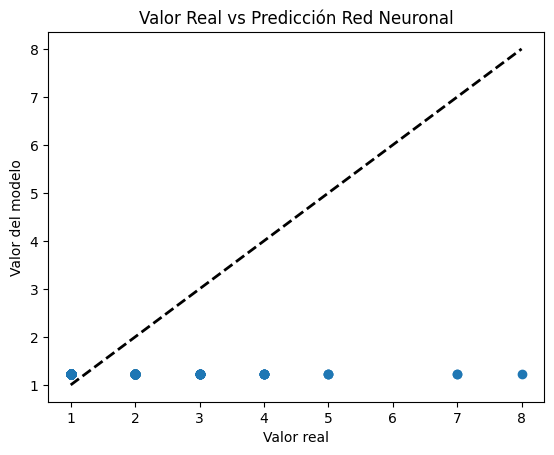

In [20]:
#Evaluación de Red Neuronal
from sklearn import metrics

Y_pred = model_NN.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['NN']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Red Neuronal')
plt.show()

SVM para Regresión - SVR

In [21]:
#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
#SVM
from sklearn.svm import SVR
modelSVM = SVR(kernel='linear') #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVR(kernel='linear')

         Arbol       Knn                  NN                SVM
mse   0.484118  1.092619  0.4980173225037954  0.517657018898782
rmse  0.695786  1.045284            0.705703           0.719484
mae   0.367701  0.464544            0.402971           0.308878
mape  0.244437  0.333447            0.271749           0.165602
max   6.304348  7.000000            6.763256            6.90031


/tmp/ipykernel_3955/82229380.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


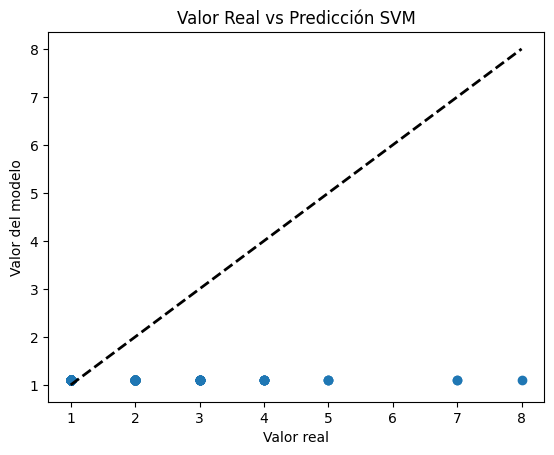

In [22]:
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['SVM']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción SVM')
plt.show()

Regresión Lineal

In [23]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)

LinearRegression()

         Arbol       Knn                  NN                SVM  \
mse   0.484118  1.092619  0.4980173225037954  0.517657018898782   
rmse  0.695786  1.045284            0.705703           0.719484   
mae   0.367701  0.464544            0.402971           0.308878   
mape  0.244437  0.333447            0.271749           0.165602   
max   6.304348  7.000000            6.763256            6.90031   

                       LR  
mse   0.47675457845997415  
rmse             0.690474  
mae              0.383472  
mape             0.264749  
max              6.703143  


/tmp/ipykernel_3955/3274394921.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


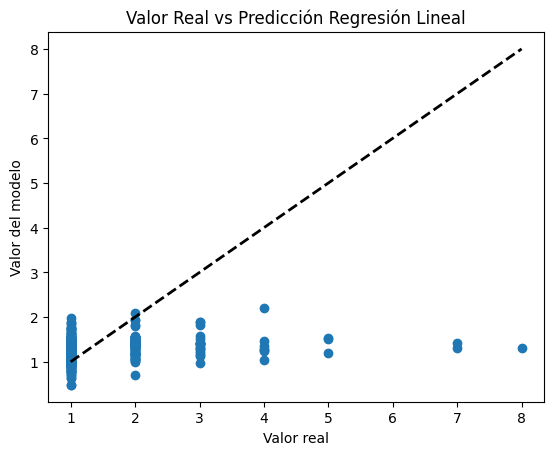

In [24]:
from sklearn import metrics

Y_pred = model_LR.predict(X_test) #30%
#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['LR']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Regresión Lineal')
plt.show()

In [25]:
#Normalizar X
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

In [26]:
#Entrenamos modelo final
model_LR.fit(X, Y) #100%

LinearRegression()

In [27]:
import pickle
filename = 'modelo-reg.pkl'
variables=X.columns._values
pickle.dump([model_LR, min_max_scaler,variables], open(filename, 'wb'))